In [1]:
from ultralytics import YOLO
from pathlib import Path

In [2]:
PROJECT_DIR = Path.cwd().parent

MODEL_PATH = PROJECT_DIR / "models" / "foodlens_yolo11n_best.pt"

IMAGE_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "foodlens_20"
    / "test"
    / "images"
)

print("Project:", PROJECT_DIR)
print("Model exists:", MODEL_PATH.exists())
print("Image folder exists:", IMAGE_DIR.exists())

Project: d:\FoodLens_AI
Model exists: True
Image folder exists: True


In [3]:
images = list(IMAGE_DIR.glob("*.jpg"))

print("Number of test images:", len(images))

for image in images[:10]:
    print(image.name)

Number of test images: 104
000000_jpg.rf.jpg
004bd4d6cd_jpg.rf.fd3a1f5647555e8ae5a4962436eebe86.jpg
006aeeea8d_jpg.rf.550facb10b9188d57b3901a365a4f5c6.jpg
01eaebcbec_jpg.rf.eb212d86817311f0ba64ee04edfd4a8e.jpg
01fe6cca57_jpg.rf.c8c506f6ed788264a664c3966c293286.jpg
040febc4fa_jpg.rf.2430426ccf1d66331d8b7c4e8230aaff.jpg
058d2b909e_jpg.rf.5061dd758dd8a85ee3f27bee4f683d6a.jpg
07f1b059cc_jpg.rf.c0990144479d3bbf44088b0b0aa42cf5.jpg
09d9a0cae7_jpg.rf.1c6b4a12917c563be04f899edd2a329d.jpg
0abcfb9143_jpg.rf.13b71a00ef7f46926a1b2b1babfa8e98.jpg


In [4]:
IMAGE_PATH = images[0]

print("Selected image:")
print(IMAGE_PATH)

Selected image:
d:\FoodLens_AI\data\processed\foodlens_20\test\images\000000_jpg.rf.jpg


In [5]:
model = YOLO(str(MODEL_PATH))

print("FoodLens model loaded successfully!")

FoodLens model loaded successfully!


In [10]:
results = model.predict(
    source=str(IMAGE_PATH),
    imgsz=640,
    conf=0.05,
    device=0,
    save=True
)

print("Prediction completed!")


image 1/1 d:\FoodLens_AI\data\processed\foodlens_20\test\images\000000_jpg.rf.jpg: 640x448 1 chapati, 1 dal makhani, 22.3ms
Speed: 402.9ms preprocess, 22.3ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 448)
Results saved to D:\FoodLens_AI\training\runs\detect\predict-2
Prediction completed!


In [11]:
print("========== FOOD DETECTION ==========")

for result in results:

    if result.boxes is None or len(result.boxes) == 0:
        print("No food detected.")
        continue

    for box in result.boxes:

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        food_name = model.names[class_id]

        print(
            f"Food: {food_name} | "
            f"Confidence: {confidence:.2%}"
        )

========== FOOD DETECTION ==========
Food: dal makhani | Confidence: 56.70%
Food: chapati | Confidence: 5.25%


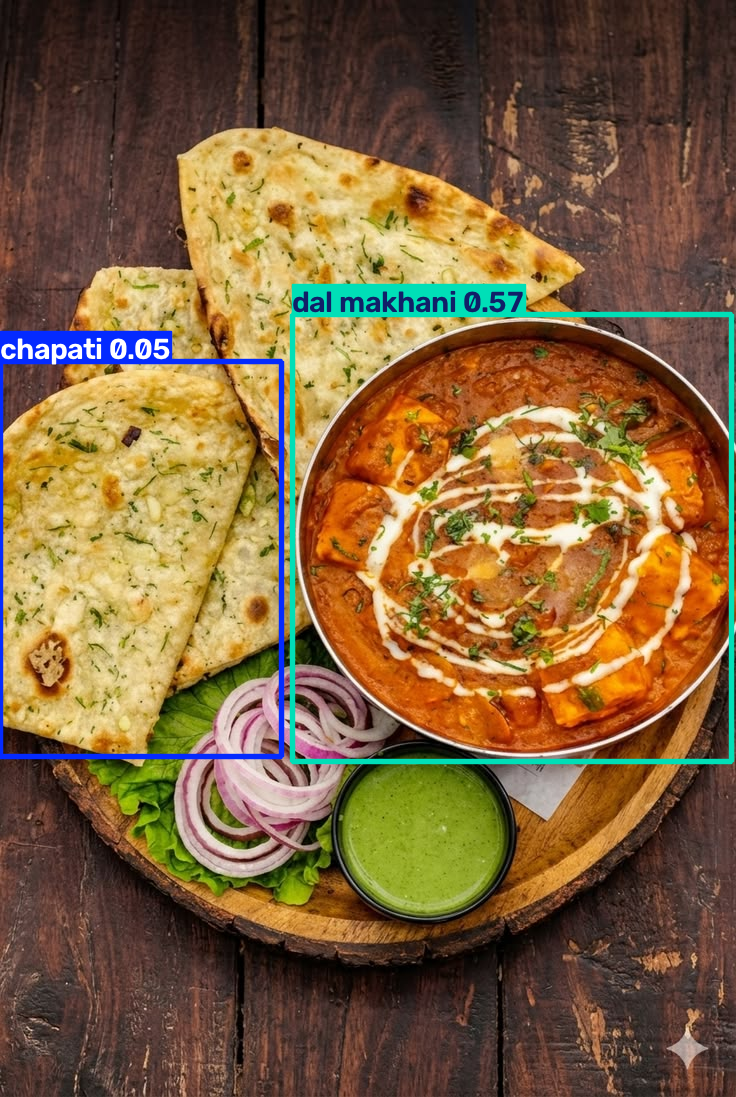

In [12]:
from IPython.display import display
from PIL import Image

result_image = results[0].plot()

display(Image.fromarray(result_image[..., ::-1]))

In [13]:
confidence_levels = [0.25, 0.10, 0.05]

for conf in confidence_levels:

    print("\n" + "=" * 45)
    print(f"CONFIDENCE THRESHOLD: {conf}")
    print("=" * 45)

    results = model.predict(
        source=str(IMAGE_PATH),
        imgsz=640,
        conf=conf,
        device=0,
        verbose=False
    )

    for result in results:

        if result.boxes is None or len(result.boxes) == 0:
            print("No detections")
            continue

        for box in result.boxes:

            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            food_name = model.names[class_id]

            print(
                f"{food_name:25s} "
                f"{confidence:.2%}"
            )


CONFIDENCE THRESHOLD: 0.25
dal makhani               56.70%

CONFIDENCE THRESHOLD: 0.1
dal makhani               56.70%

CONFIDENCE THRESHOLD: 0.05
dal makhani               56.70%
chapati                   5.25%


In [14]:
from pathlib import Path

LABEL_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "foodlens_20"
    / "test"
    / "labels"
)

multi_food_images = []

for label_file in LABEL_DIR.glob("*.txt"):

    with open(label_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    # More than one bounding box = multiple food objects
    if len(lines) >= 2:
        multi_food_images.append(label_file.stem)

print("Images containing multiple food objects:", len(multi_food_images))

for name in multi_food_images[:20]:
    print(name)

Images containing multiple food objects: 37
004bd4d6cd_jpg.rf.fd3a1f5647555e8ae5a4962436eebe86
09d9a0cae7_jpg.rf.1c6b4a12917c563be04f899edd2a329d
0dddfcb42d_jpg.rf.bc3f4abb0bd11655bb2c5100218dde6e
10e2670c3b_jpg.rf.4af788564517afe02be8a5d31423d1cc
14b6125138_jpg.rf.47ad5328aa71b5c05a4ec8a741399b5b
14cfe620e9_jpg.rf.58f902d8d786800f5fe6061274af972f
1a21cfe891_jpg.rf.5dfa3be870312b45fd8880456d5bf433
1ae2362cff_jpg.rf.c104fe72a9018dc602854ebedba8b265
1b3323c25f_jpg.rf.0a77c037fd9eaac09a4502fc53f53f3e
2c9d6d7b72_jpg.rf.f44e12064d707f78fda1a778ffe86a19
2e453cba80_jpg.rf.48c81c24200c6432b18df618c8f5054f
3d0b446af6_jpg.rf.5840df5b35f62a2a68e385294c754844
3eeba485b4_jpg.rf.024b5cf0a7e38772baab563a803d316c
4c2e6d837f_jpg.rf.69866a74583862413fb91977823cb81b
4cf2feea33_jpg.rf.db823be2ef9f4f58811cffd4e3be67a0
4d4798b9d2_jpg.rf.1e189895e3a9ad1ec8294ba3cac9732f
4fe25df782_jpg.rf.12e5b3176e989f3750460d9f12cd9969
5b3f7359b7_jpg.rf.8d65b9a6846dbb43a90c1fd06b3a4d3a
5e5fcfafab_jpg.rf.6f39caa94174e9d3c44d

In [15]:
multi_image_name = multi_food_images[0]

IMAGE_PATH = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "foodlens_20"
    / "test"
    / "images"
    / f"{multi_image_name}.jpg"
)

print("Testing image:")
print(IMAGE_PATH)

Testing image:
d:\FoodLens_AI\data\processed\foodlens_20\test\images\004bd4d6cd_jpg.rf.fd3a1f5647555e8ae5a4962436eebe86.jpg


In [16]:
image_candidates = list(
    IMAGE_DIR.glob(f"{multi_image_name}.*")
)

IMAGE_PATH = image_candidates[0]

print("Testing image:")
print(IMAGE_PATH)

Testing image:
d:\FoodLens_AI\data\processed\foodlens_20\test\images\004bd4d6cd_jpg.rf.fd3a1f5647555e8ae5a4962436eebe86.jpg


In [17]:
results = model.predict(
    source=str(IMAGE_PATH),
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)

print("Prediction completed!")

Prediction completed!


In [18]:
print("========== DETECTIONS ==========")

for result in results:

    if result.boxes is None or len(result.boxes) == 0:
        print("No detections")
        continue

    for box in result.boxes:

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        food_name = model.names[class_id]

        print(
            f"Food: {food_name} | "
            f"Confidence: {confidence:.2%}"
        )

========== DETECTIONS ==========
Food: aloo tikki | Confidence: 35.08%
Food: jalebi | Confidence: 29.57%


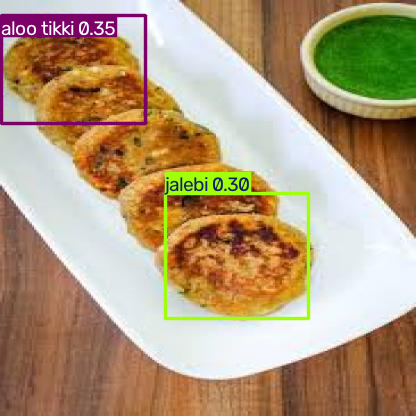

In [19]:
from IPython.display import display
from PIL import Image

result_image = results[0].plot()

display(Image.fromarray(result_image[..., ::-1]))